In [1]:
import polars as pl
import itertools
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
from scipy import stats
from collections import defaultdict

from piepy.core.statistics import bootstrap_confidence_interval
from piepy.plotters.colors.color import Color
from piepy.psychophysics.wheel.detection.wheelDetectionExperimentHub import WheelDetectionExperimentHub
from piepy.psychophysics.wheel.detection.wheelDetectionGroupedAggregator import WheelDetectionGroupedAggregator
from piepy .core.data_functions import make_subsets
from piepy.plotters.plotting_utils import (
    set_style, 
    make_dot_cloud,
    override_plots, 
    pval_plotter)

In [47]:
# without KC148 dorsal (no effect)
session_list = [
    # KC147 dorsal
    "240307_KC147_detect_opto120_dorsalCNO__1P_KC",
    "240228_KC147_detect_opto120_dorsal__1P_KC",
    "240308_KC147_detect_opto120_dorsal__1P_KC",
    # KC149 dorsal
    "240227_KC149_detect_opto120_dorsal__1P_KC",
    "240307_KC149_detect_opto120_dorsalCNO__1P_KC",
    "240308_KC149_detect_opto120_dorsal__1P_KC",
    # KC148 dorsal
    # "240227_KC148_detect_opto120_dorsal__1P_KC",
    # "240307_KC148_detect_opto120_dorsalCNO__1P_KC",
    # "240308_KC148_detect_opto120_dorsal__1P_KC",
    #KC147 ventralPM
    "240305_KC147_detect_opto120_ventralPM__1P_KC",
    "240321_KC147_detect_opto120_ventralPMCNO__1P_KC",
    "240326_KC147_detect_opto120_ventralPM__1P_KC",
    # kC148 ventralPM
    "240305_KC148_detect_opto120_ventralPM__1P_KC",
    "240321_KC148_detect_opto120_ventralPMCNO__1P_KC",
    "240326_KC148_detect_opto120_ventralPM__1P_KC"
]

In [10]:
# only dorsal
session_list = [
    "240228_KC147_detect_opto120_dorsal__1P_KC",
    "240227_KC148_detect_opto120_dorsal__1P_KC",
    "240227_KC149_detect_opto120_dorsal__1P_KC",
    
    "240307_KC147_detect_opto120_dorsalCNO__1P_KC",
    "240307_KC148_detect_opto120_dorsalCNO__1P_KC",
    "240307_KC149_detect_opto120_dorsalCNO__1P_KC",
    
    "240308_KC147_detect_opto120_dorsal__1P_KC",
    "240308_KC148_detect_opto120_dorsal__1P_KC",
    "240308_KC149_detect_opto120_dorsal__1P_KC",
    # "240305_KC147_detect_opto120_ventralPM__1P_KC",
    # "240305_KC148_detect_opto120_ventralPM__1P_KC",
    # "240321_KC147_detect_opto120_ventralPMCNO__1P_KC",
    # "240321_KC148_detect_opto120_ventralPMCNO__1P_KC",
    # "240326_KC147_detect_opto120_ventralPM__1P_KC",
    # "240326_KC148_detect_opto120_ventralPM__1P_KC"
]

In [36]:
# all sessions
session_list = [
    "240228_KC147_detect_opto120_dorsal__1P_KC",
    "240227_KC148_detect_opto120_dorsal__1P_KC",
    "240227_KC149_detect_opto120_dorsal__1P_KC",
    
    "240307_KC147_detect_opto120_dorsalCNO__1P_KC",
    "240307_KC148_detect_opto120_dorsalCNO__1P_KC",
    "240307_KC149_detect_opto120_dorsalCNO__1P_KC",
    
    "240308_KC147_detect_opto120_dorsal__1P_KC",
    "240308_KC148_detect_opto120_dorsal__1P_KC",
    "240308_KC149_detect_opto120_dorsal__1P_KC",
    
    "240305_KC147_detect_opto120_ventralPM__1P_KC",
    "240305_KC148_detect_opto120_ventralPM__1P_KC",
    
    "240321_KC147_detect_opto120_ventralPMCNO__1P_KC",
    "240321_KC148_detect_opto120_ventralPMCNO__1P_KC",
    
    "240326_KC147_detect_opto120_ventralPM__1P_KC",
    "240326_KC148_detect_opto120_ventralPM__1P_KC"
]

In [13]:
# only ventral
session_list = [
    # KC147 dorsal
    # "240307_KC147_detect_opto120_dorsalCNO__1P_KC",
    # "240228_KC147_detect_opto120_dorsal__1P_KC",
    # "240308_KC147_detect_opto120_dorsal__1P_KC",
    # KC149 dorsal
    # "240227_KC149_detect_opto120_dorsal__1P_KC",
    # "240307_KC149_detect_opto120_dorsalCNO__1P_KC",
    # "240308_KC149_detect_opto120_dorsal__1P_KC",
    # KC148 dorsal
    # "240227_KC148_detect_opto120_dorsal__1P_KC",
    # "240307_KC148_detect_opto120_dorsalCNO__1P_KC",
    # "240308_KC148_detect_opto120_dorsal__1P_KC",
    #KC147 ventralPM
    "240305_KC147_detect_opto120_ventralPM__1P_KC",
    "240321_KC147_detect_opto120_ventralPMCNO__1P_KC",
    "240326_KC147_detect_opto120_ventralPM__1P_KC",
    # kC148 ventralPM
    "240305_KC148_detect_opto120_ventralPM__1P_KC",
    "240321_KC148_detect_opto120_ventralPMCNO__1P_KC",
    "240326_KC148_detect_opto120_ventralPM__1P_KC"
]

In [42]:
# cherry picked
session_list = [
    # KC147 dorsal
    "240307_KC147_detect_opto120_dorsalCNO__1P_KC",
    "240228_KC147_detect_opto120_dorsal__1P_KC",
    "240308_KC147_detect_opto120_dorsal__1P_KC",
    # KC149 dorsal
    "240227_KC149_detect_opto120_dorsal__1P_KC",
    "240307_KC149_detect_opto120_dorsalCNO__1P_KC",
    "240308_KC149_detect_opto120_dorsal__1P_KC",
    # KC148 dorsal
    # "240227_KC148_detect_opto120_dorsal__1P_KC",
    # "240307_KC148_detect_opto120_dorsalCNO__1P_KC",
    # "240308_KC148_detect_opto120_dorsal__1P_KC",
    #KC147 ventralPM
    "240305_KC147_detect_opto120_ventralPM__1P_KC",
    "240321_KC147_detect_opto120_ventralPMCNO__1P_KC",
    "240326_KC147_detect_opto120_ventralPM__1P_KC",
    # kC148 ventralPM
    # "240305_KC148_detect_opto120_ventralPM__1P_KC",
    # "240321_KC148_detect_opto120_ventralPMCNO__1P_KC",
    # "240326_KC148_detect_opto120_ventralPM__1P_KC"
]

In [ ]:
# only KC148
session_list = [
    # KC147 dorsal
    # "240307_KC147_detect_opto120_dorsalCNO__1P_KC",
    # "240228_KC147_detect_opto120_dorsal__1P_KC",
    # "240308_KC147_detect_opto120_dorsal__1P_KC",
    # KC149 dorsal
    # "240227_KC149_detect_opto120_dorsal__1P_KC",
    # "240307_KC149_detect_opto120_dorsalCNO__1P_KC",
    # "240308_KC149_detect_opto120_dorsal__1P_KC",
    # KC148 dorsal
    # "240227_KC148_detect_opto120_dorsal__1P_KC",
    # "240307_KC148_detect_opto120_dorsalCNO__1P_KC",
    # "240308_KC148_detect_opto120_dorsal__1P_KC",
    #KC147 ventralPM
    # "240305_KC147_detect_opto120_ventralPM__1P_KC",
    # "240321_KC147_detect_opto120_ventralPMCNO__1P_KC",
    # "240326_KC147_detect_opto120_ventralPM__1P_KC",
    # kC148 ventralPM
    "240305_KC148_detect_opto120_ventralPM__1P_KC",
    "240321_KC148_detect_opto120_ventralPMCNO__1P_KC",
    "240326_KC148_detect_opto120_ventralPM__1P_KC"
]

In [48]:
hub = WheelDetectionExperimentHub()
# load from session list
hub.set_data(session_list,
             load_sessions=True,
             make_summary=True)
# hub.data.write_parquet("250206_experiment_data.parquet")


240308_KC147_detect_opto120_dorsal__1P_KC
240321_KC147_detect_opto120_ventralPMCNO__1P_KC
240305_KC147_detect_opto120_ventralPM__1P_KC
240308_KC149_detect_opto120_dorsal__1P_KC
240307_KC147_detect_opto120_dorsalCNO__1P_KC
240307_KC149_detect_opto120_dorsalCNO__1P_KC
240228_KC147_detect_opto120_dorsal__1P_KC
240227_KC149_detect_opto120_dorsal__1P_KC
240326_KC147_detect_opto120_ventralPM__1P_KC
240305_KC148_detect_opto120_ventralPM__1P_KC
240321_KC148_detect_opto120_ventralPMCNO__1P_KC
240326_KC148_detect_opto120_ventralPM__1P_KC


animalid,area,stimulus_count,stim_combination,opto_targets,isTitrated,isCNO,total_trials,stim_type,experiment_count,date,session_ids,stat_total_trial_count,stat_early_trial_count,stat_stim_trial_count,stat_correct_trial_count,stat_miss_trial_count,stat_catch_trial_count,stat_opto_trial_count,stat_opto_ratio,stat_nonopto_hit_rate,stat_correct_rate,stat_hit_rate,stat_false_alarm_rate,stat_nogo_rate,stat_median_response_time,stat_median_reaction_time,stat_d_prime,stat_easy_trial_count,stat_easy_hit_rate,stat_easy_nogo_rate,stat_easy_median_response_time,stat_easy_median_reaction_time
str,str,i32,str,i32,bool,bool,u32,list[str],u32,list[date],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[f64],list[f64],list[f64],list[f64]
"""KC147""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,716,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",2,"[2024-02-28, 2024-03-08]","[7258320, 6939483]","[340, 376]","[104, 162]","[211, 195]","[119, 88]","[92, 107]","[25, 19]","[117, 104]","[34.412, 27.66]","[75.532, 65.934]","[35.0, 23.404]","[56.398, 45.128]","[30.588, 43.085]","[43.602, 54.872]","[283.0, 299.0]","[195.0, 206.4]","[0.668631, 0.051782]","[49, 41]","[91.837, 92.683]","[8.163, 7.317]",[266.0],"[178.2, 182.2]"
"""KC147""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,true,504,"[""0.04cpd_8.0Hz"", ""0.16cpd_0.5Hz""]",1,[2024-03-07],[360478],[504],[236],[240],[115],[125],[28],[127],[25.198],[76.991],[22.817],[47.917],[46.825],[52.083],[316.0],[220.8],[0.027433],[53],[100.0],[0.0],[282.0],[201.0]
"""KC147""","""ventralPM""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,1013,"[""0.04cpd_8.0Hz"", ""0.16cpd_0.5Hz""]",2,"[2024-03-05, 2024-03-26]","[9684610, 489146]","[315, 698]","[103, 354]","[189, 304]","[93, 178]","[96, 126]","[23, 40]","[102, 117]","[32.381, 16.762]","[59.77, 67.38]","[29.524, 25.501]","[49.206, 58.553]","[32.698, 50.716]","[50.794, 41.447]","[283.5, 332.5]","[197.1, 204.4]","[0.428364, 0.198113]","[39, 79]","[84.615, 84.81]","[15.385, 15.19]",[266.0],"[185.6, 162.6]"
"""KC147""","""ventralPM""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,true,478,"[""0.04cpd_8.0Hz"", ""0.16cpd_0.5Hz""]",1,[2024-03-21],[8846399],[478],[179],[299],[161],[138],[0],[97],[20.293],[59.901],[33.682],[53.846],[37.448],[46.154],[316.0],[238.8],[0.416566],[80],[85.0],[15.0],[282.0],[200.4]
"""KC148""","""ventralPM""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,1227,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",2,"[2024-03-05, 2024-03-26]","[783552, 8058763]","[304, 923]","[139, 434]","[151, 489]","[75, 319]","[76, 170]","[14, 0]","[0, 150]","[0.0, 16.251]","[49.669, 70.796]","[24.671, 34.561]","[49.669, 65.235]","[45.724, 47.021]","[50.331, 34.765]","[282.0, 283.0]","[184.8, 159.3]","[0.099092, 0.466415]","[89, 148]","[61.798, 90.541]","[38.202, 9.459]","[266.0, 250.0]","[174.0, 97.7]"
"""KC148""","""ventralPM""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,true,740,"[""0.04cpd_8.0Hz"", ""0.16cpd_0.5Hz""]",1,[2024-03-21],[4964896],[740],[397],[313],[190],[123],[30],[100],[13.514],[68.075],[25.676],[60.703],[53.649],[39.297],[333.0],[257.0],[0.179992],[100],[89.0],[11.0],[283.0],[207.6]
"""KC149""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,817,"[""0.04cpd_8.0Hz"", ""0.16cpd_0.5Hz""]",2,"[2024-02-27, 2024-03-08]","[5675621, 5245040]","[353, 464]","[114, 207]","[213, 233]","[126, 108]","[87, 125]","[26, 24]","[124, 131]","[35.127, 28.233]","[92.135, 78.431]","[35.694, 23.276]","[59.155, 46.352]","[32.295, 44.612]","[40.845, 53.648]","[332.5, 474.5]","[235.7, 361.8]","[0.690999, 0.043901]","[39, 56]","[100.0, 83.929]","[0.0, 16.071]","[282.0, 383.0]","[189.2, 270.4]"
"""KC149""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,true,479,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2024-03-07],[9228514],[479],[237],[217],[110],[107],[25],[123],[25.678],[86.17],[22.965],[5

 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['early', 'hit', 'miss']


/Users/kaan/miniconda3/envs/piepy/lib/python3.10/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/kaan/code/piepy/piepy/core/statistics.py:54: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  res = bootstrap(


 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['early', 'hit', 'miss']
 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['miss', 'early', 'hit']
 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['early', 'miss', 'hit']
0.25
0.625
0.125
0.25
0.625
0.125
0.25
0.625
0.125
0.625
0.875
0.875
0.625
0.875
0.875
0.625
0.875
0.875


/var/folders/jg/zg43p_f517b7tfj20zr4kfrr0000gn/T/ipykernel_32403/348551917.py:112: UserWarning: You passed a edgecolor/edgecolors ('w') for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


Text(0, 0.5, 'hit_rate')

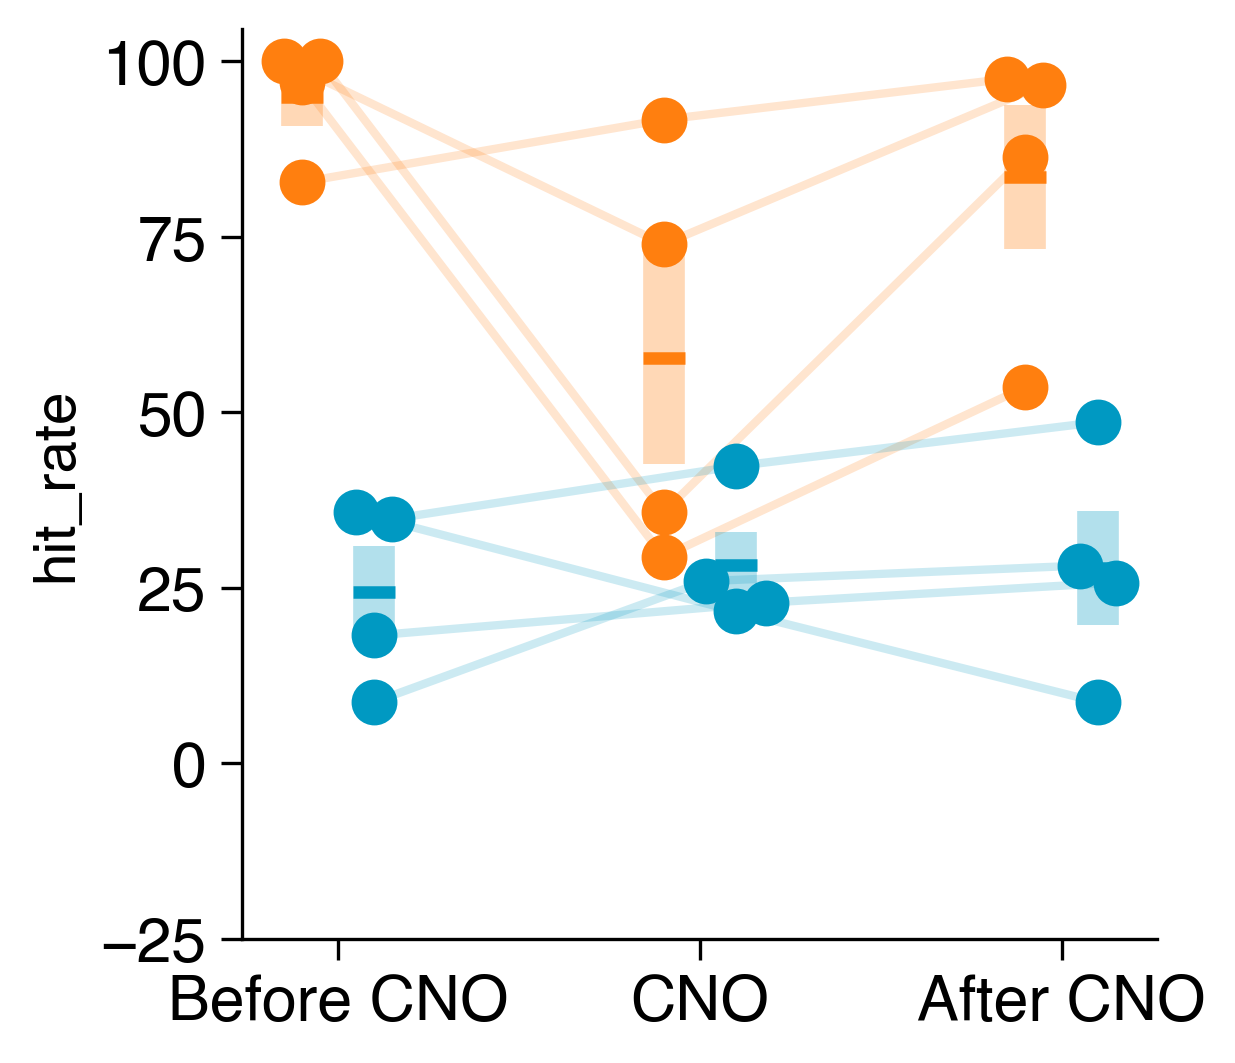

In [65]:
cm = 1/2.54
plot_with = "sem"
effect_metric = "hit_rate"
# effect_metric = "delta_hit_rate"

set_style("print")
fig, ax = plt.subplots(1, 1, figsize=(10*cm, 10*cm))
clr = Color(task="detection")

hr_diffs = defaultdict(list)
stypes = []
for filt_tup in make_subsets(hub.data,["animalid","area"]):
    filt_df = filt_tup[-1]
    
    if not filt_df.is_empty():
        
        analyzer = WheelDetectionGroupedAggregator()
        analyzer.set_data(data=filt_df)
        analyzer.group_data(group_by=["stim_type", "stim_side", "contrast", "baredate", "opto_pattern"])
        analyzer.calculate_hit_rates()
        analyzer.calculate_opto_pvalues()
        
        # contra side and 50%
        nonearly_data = analyzer.grouped_data.drop_nulls("contrast").filter(pl.col("stim_side")!="ipsi")
        plot_data = nonearly_data.filter(pl.col("contrast")==0.5)
        
        q = (plot_data.group_by(["stim_type","baredate"])
        .agg(
            [
                (pl.col("hit_rate").filter(pl.col("opto_pattern")==0).get(0)),
                (pl.col("hit_rate").filter(pl.col("opto_pattern")==-1).get(0) - pl.col("hit_rate").filter(pl.col("opto_pattern")==0).get(0)).alias("delta_hit_rate"),
                ((pl.col("hit_rate").filter(pl.col("opto_pattern")==-1).get(0) - pl.col("hit_rate").filter(pl.col("opto_pattern")==0).get(0))/pl.col("hit_rate").filter(pl.col("opto_pattern")==-1).get(0)).alias("BSI")
            ]
        ).sort(["stim_type","baredate"])
        )
        
        uniq_stype = q["stim_type"].unique(maintain_order=True)
        for s in uniq_stype:
            hr_diffs[s].append(q.filter(pl.col("stim_type")==s)[effect_metric].to_list())

for k,v in hr_diffs.items():
    data_mat = np.array(v) 
    data_mat_x = np.zeros_like(data_mat)
    offset = -0.1 if k=="0.04cpd_8.0Hz" else 0.1
    x_axis = [ii+offset for ii in [0,1,2]]
    for j in range(data_mat.shape[1]):
        
        x_points = make_dot_cloud(data_mat[:,j],
                                  j+offset,
                                  bin_width=0.05,
                                  width=0.1)
        data_mat_x[:,j] = x_points
        
        ax.scatter(x_points,
                   data_mat[:,j]*100,
                   zorder=2,
                   c=clr.stim_keys[f"{k}_-1"]["color"])
        
        
        for p1,p2 in list(itertools.combinations([x for x in range(data_mat.shape[1])], 2)):
            d1 = data_mat[:,p1]
            d2 = data_mat[:,p2]

            res = stats.wilcoxon(d1, d2, nan_policy="omit")

            p = res.pvalue
            print(p)
            
            ax = pval_plotter(ax,p,[p1,p2],
                            loc=100)
    
    for i in range(data_mat_x.shape[0]):

        ax.plot(data_mat_x[i,:],
                data_mat[i,:]*100,
                linewidth=2,
                alpha=0.2,
                c=clr.stim_keys[f"{k}_-1"]["color"],
                zorder=0)
    
    # plot the means and shaded regions
    if plot_with == "conf":         
        means,ci_plus,ci_neg = np.apply_along_axis(bootstrap_confidence_interval,axis=0,arr=data_mat,statistic=np.nanmean)
    elif plot_with == "sem":
        means = np.nanmean(data_mat,axis=0)
        ci_plus = stats.sem(data_mat,axis=0,nan_policy="omit")
        ci_neg = stats.sem(data_mat,axis=0,nan_policy="omit")
    elif plot_with =="iqr":
        means = np.nanmean(data_mat,axis=0)
        ci_plus = stats.iqr(data_mat,axis=0,nan_policy="omit")
        ci_neg = stats.iqr(data_mat,axis=0,nan_policy="omit")
    
    means *= 100
    ci_plus *= 100
    ci_neg *= 100    
    
    # shaded 95% CI
    ax.errorbar(
        x_axis,
        means,
        yerr=(ci_plus,
                ci_neg),
        color=clr.stim_keys[f"{k}_-1"]["color"],
        alpha=0.3,
        zorder=2,
        linewidth=0,
        elinewidth=10,
        markersize=0
    )
        
    # # means
    ax.scatter(
        x_axis,
        means,
        s = (plt.rcParams["lines.markersize"] ** 2),
        c = clr.stim_keys[f"{k}_-1"]["color"],
        marker="_",
        linewidths = 3,
        edgecolors = "w",
        zorder=3
    )
    
ax.set_xticks([0,1,2])
ax.set_xticklabels(["Before CNO","CNO","After CNO"])

ax.set_yticks([-25,0,25,50,75,100])
ax.set_ylabel(f"{effect_metric}")

In [5]:
savename = f"{dt.strftime(dt.today(),'%y%m%d')}_sessionCNO_through_time_delta_hit_rate"
fig.savefig(f"pdf/{savename}.pdf")
fig.savefig(f"svg/{savename}.svg")

In [66]:
CNO_NAME = {0:"preCNO",
            1:"wCNO",
            2:"afterCNO"}

dabest_mat = np.zeros((data_mat.shape[0],
                       1 + (data_mat.shape[1]*len(hr_diffs.keys()))))
dabest_mat[:] = np.nan
_schema = ["exp_id"]
for j,k in enumerate(hr_diffs.keys()):
    _data_mat = np.array(hr_diffs[k]) 

    col_k = [f"{k}_{CNO_NAME[i]}" for i in range(_data_mat.shape[1])]
    _schema.extend(col_k)
    
    dabest_mat[:,j*3+1:j*3+1+_data_mat.shape[1]] = _data_mat*100
dabest_mat[:,0] = np.arange(_data_mat.shape[0])

to_dabest = pl.from_numpy(data=dabest_mat,schema=_schema)
to_dabest

exp_id,0.04cpd_8.0Hz_preCNO,0.04cpd_8.0Hz_wCNO,0.04cpd_8.0Hz_afterCNO,0.16cpd_0.5Hz_preCNO,0.16cpd_0.5Hz_wCNO,0.16cpd_0.5Hz_afterCNO
f64,f64,f64,f64,f64,f64,f64
0.0,100.0,35.714286,86.363636,35.714286,21.621622,8.695652
1.0,100.0,73.913043,96.666667,8.695652,25.925926,28.125
2.0,82.758621,91.666667,97.5,34.782609,42.307692,48.571429
3.0,96.969697,29.411765,53.571429,18.181818,22.857143,25.714286


In [67]:
to_dabest.write_parquet("250424_CNO_throughout_sessions_DABEST.parquet")